# Overview

`oplanet` is a python package implemented for querying databases necessary for research in exoplanetary science. It provides various function who enable:
- querying the *Simbad* database for checking star aliases and properties.
- querying the *NASA Exoplanet Archive* database for orbital parameters of information about the planetary system
- querying the *SVO* database for filters (and saving the information to cache, as the database is often down)
- querying the *Vizier* database for photometric points.

## Installation

This package is available on pip:
```bash
pip install oplanet
python -m oplanet.setup
```
but it can also be installed from [GitHub](https://github.com/ProfesseurShadoko/oplanet) with 
```bash
pip install "git+https://github.com/ProfesseurShadoko/oplanet.git"
python -m oplanet.setup
```

In [1]:
from oplanet import *
from oakley import * # not necessary, just pretty prints

`oplanet` is now ready to be used. We will take a look at each one of its capabilities one by one.

___

## 1. The Simbad API

Because papers and databases might use different naming convention, `oplanet` provides a way to obtain aliases for any given star name, compare names together. It can also obtainthe distance to the object, and it coordinates.

let's start with a difficult example, *Beta Pictoris*.

In [2]:
star_name = "bet Pic"
parsed_star_name = parse_star_name(star_name)
star_aliases = get_star_aliases(star_name)
distance_pc = get_distance_pc(star_name)
coords = get_star_coords(star_name)
sptype = get_spectral_type(star_name)

Message(f"Results of queries to {star_name}:").list({
    "Star Name": parsed_star_name, # closest Simbad valid name
    "Aliases": star_aliases,
    "Distance (pc)": distance_pc,
    "Coordinates (RA, Dec)": coords,
    "Spectral Type": sptype
})

[i] Results of queries to bet Pic:
 > Star Name:             * bet Pic
 > Aliases:               ['HD 39060', 'HIP 27321', 'GJ 219', 'GJ 219.0', 'HR 2020', '2MASS J05471708-5103594', 'TYC 8099-1392-1', 'SAO 234134', 'TIC 270577175', 'WISEA J054717.10-510358.4', 'Gaia DR3 4792774797545800832', 'PLX 1339', '* bet Pic', 'CD-51 1620', 'CPC 0 3123', 'CPD-51 774', 'GC 7287', 'GCRV 3614', 'GEN# +1.00039060', 'GSC 08099-01392', 'HIC 27321', 'IRAS 05460-5104', 'JP11 1271', 'CNS5 1437', 'PPM 334622', 'ROT 934', 'SKY# 9519', 'TD1 5440', 'UBV 5954', 'UBV M 11539', '[DML87] 189', 'uvby98 100039060', 'Gaia DR2 4792774797545105664', 'JCMTSE J054716.8-510356', 'PLX 1339.00', 'PSCz P05460-5104', 'Renson 10480', 'AKARI-IRC-V1 J0547170-510359', 'WISE J054717.01-510357.5', 'WEB 5372', 'JCMTSF J054716.8-510402']
 > Distance (pc):         19.63452298908124
 > Coordinates (RA, Dec): (np.float64(86.82119870875), np.float64(-51.066511426388885))
 > Spectral Type:         A6V


As you can see, *Beta Pictoris* isn't actually a valid alias, though Simbad still recognizes it.

___

## 2. The SVO API

Retrieving filter information from SVO can also be a pain, espacially when the website is down, which seems to happen quite often. Hence, to code caches everything it loads into a `json` file. When loading the filters for the very first time, you do need to provide the facility the filter corresponds to. Once this is done, you only need the name of the filter.

[i] Filter F1140C properties:
 > ID:                       JWST/MIRI.F1140C
 > Facility:                 JWST
 > Instrument:               MIRI
 > Mean wavelength (m):      1.1316e-05
 > Pivot wavelength (m):     1.1310e-05
 > Effective wavelength (m): 1.1301e-05
 > Effective bandwidth (m):  6.0365e-07
 > Bandwidth (m):            1.7666e-07
 > Detector type:            energy_counter


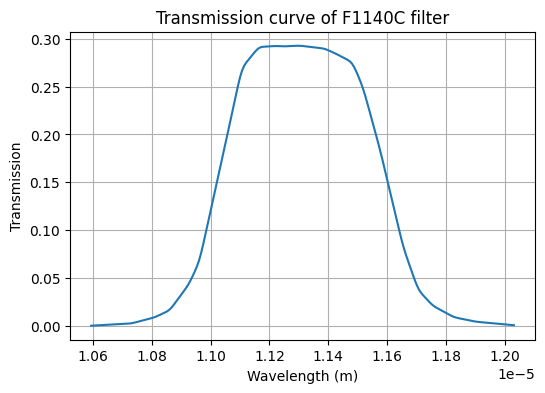

In [3]:
sfilter = SFilter(
    "F1140C",
    # facility="JWST",       # not necessary, as JWST filters are downloaded
    # instrument="MIRI",     # when running oplanet.setup
)
sfilter.display()
sfilter.plot()

Several methods are available to access the filters information. **Be careful, all units are in USI**. You can also get/plot all filters for a given instrument.

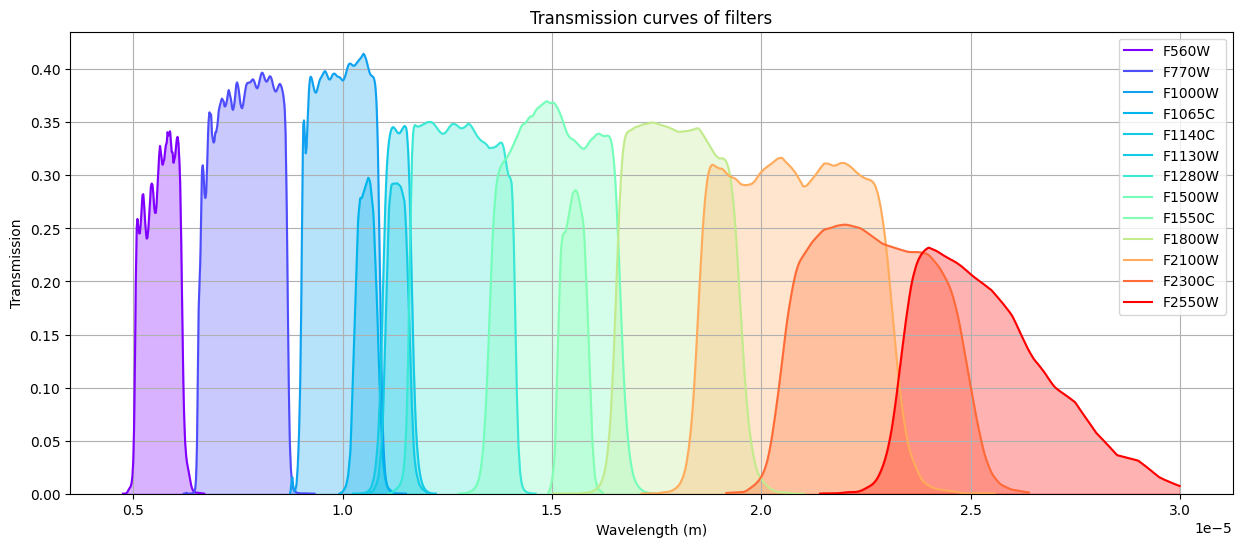

In [4]:
miri_filters = SFilter.get_filters("JWST", "MIRI")
SFilter.plot_all([filter.id for filter in miri_filters])

Finally, several funhctionnalities allow you to efficiently propagate models and spectra through the filter's transmission. For instance:

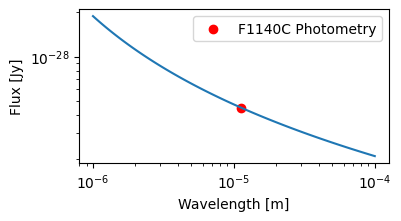

In [5]:
import numpy as np
import matplotlib.pyplot as plt
wavelengths = np.logspace(-6, -4, 100) # in meters!
fluxes = 1e-15 * ((np.log(wavelengths) - np.log(0.1e-6)) / 1e-6)**(-2) # in W/m^2/m

plt.figure(figsize=(4, 2))
plt.plot(wavelengths, fluxes)
plt.ylabel("Flux [Jy]")
plt.xlabel("Wavelength [m]")
plt.xscale("log")
plt.yscale("log")
flux_jy = sfilter.photometry(wavelengths, fluxes, flux_type="nu")
plt.scatter(sfilter.wl_central, flux_jy, color="red", label=f"{sfilter.name} Photometry")
plt.legend()
plt.show()

It also helps you choose the wavelengths to propagate in a simple way, using *equal weight bins*. In other words, it chooses wavelengths so that 
$$
\frac{\int F(\lambda) T(\lambda) d \lambda}{\int T(\lambda) d\lambda} \approx \frac{1}{N}\sum_{i=0}^N F(\lambda_i)
$$

This way, the filte ris naturally better sampled where transmission is high.

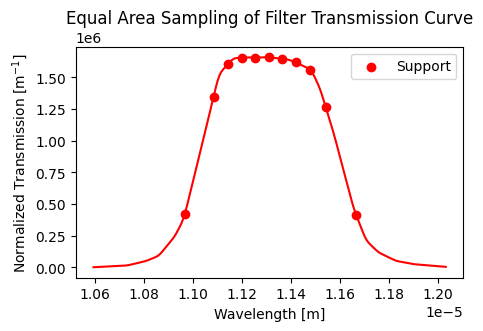

In [6]:
filter = SFilter("F1140C")
wavelengths = filter.support(11)

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(5, 3))
plt.plot(filter.wl, filter.tr / np.trapezoid(filter.tr, filter.wl), color="red")
plt.scatter(wavelengths, np.interp(wavelengths, filter.wl, filter.tr / np.trapezoid(filter.tr, filter.wl)), color="red", label="Support")
plt.xlabel(f"Wavelength [m]")
plt.ylabel("Normalized Transmission [m$^{-1}$]")
plt.legend()
plt.title("Equal Area Sampling of Filter Transmission Curve")
plt.show()
plt.show()

Finally, the `SFilter` class knows how to translate fluxes to apparent magnitudes.

In [7]:
mag = 16
flux_jy = sfilter.mag2jy(mag)
Message(f"Flux of {mag} mag in {sfilter.name} filter: {flux_jy:.2e} Jy")

[i] Flux of 16 mag in F1140C filter: 1.18e-05 Jy


___

## 3. The Vizier API

This is a way of getting the flux of a given star at a given wavelength or for a given filter. It queries from the Vizier API several photometric points (WISE, GAIA, etc.).

[#] Photometry for star HD 260655 loaded from cache.
[~] Fitting spline to photometry... (0.209ms)


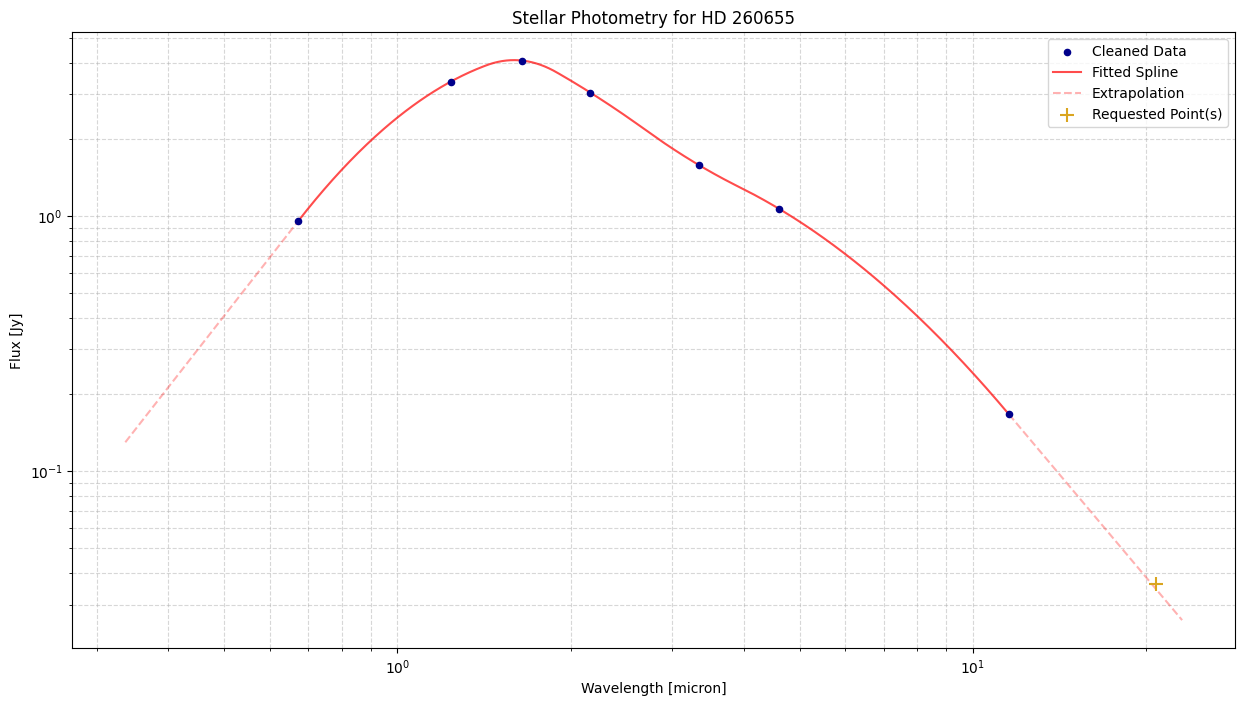

In [1]:
from oplanet import *
from oakley import *

flux_jy = get_photometry_jy("HD 260655", "F2100W", show=True)

By default, the extrapolation is done with a linear fit. At higher wavelengths however, a blackbody curve could be more accurate.

[#] Photometry for star HD 260655 loaded from cache.
[~] Fitting spline to photometry... (0.147ms)


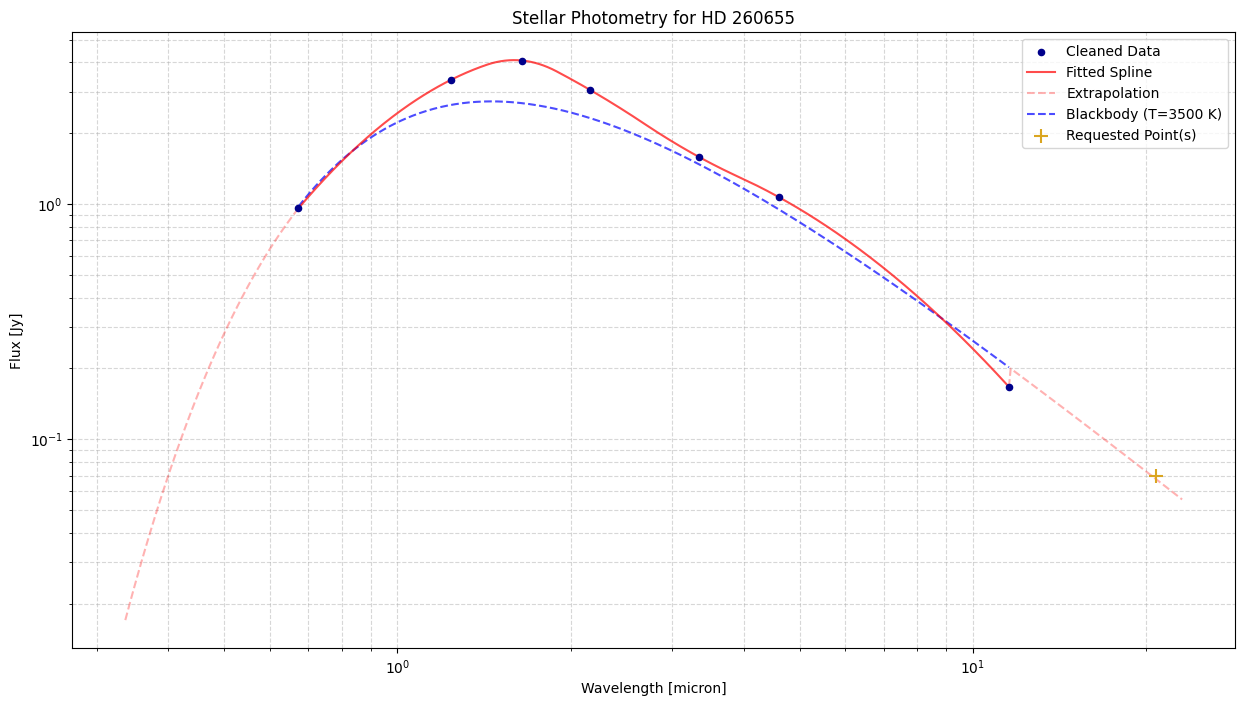

[i] Flux with and without temperature correction:
 > Flux (Jy) without T_eff:   0.0360603129938395
 > Flux (Jy) with T_eff:      0.06959813116924661
 > Effective temperature (K): 3500


In [4]:
T_eff = 3500
flux_jy_bb = get_photometry_jy("HD 260655", "F2100W", show=True, T_eff=T_eff)
Message("Flux with and without temperature correction:").list({
    "Flux (Jy) without T_eff": flux_jy,
    "Flux (Jy) with T_eff": flux_jy_bb,
    "Effective temperature (K)": T_eff
})

Just for fun, let's use `SFilter` to estimate the number of electrons that such a flux would correspond to.

In [9]:
sfilter = SFilter("F1500W")
c = 3e8
Flambda = flux_jy * 1e-26 * c / sfilter.wl_pivot**2
N_electrons = sfilter.get_nphotons(
    Flambda, A=25.4, exposure_time=3600 # A is telescope effective area in m^2
) # since QE is inscluded in SVO filter profiles, this is a number of electrons actually

Message("Number of electrons detected in 1 hour:").list({
    "Flux (Jy)": flux_jy,
    "Flux (W/m^2/m)": Flambda,
    "Number of electrons": f"{N_electrons:_.0f}"
})

[i] Number of electrons detected in 1 hour:
 > Flux (Jy):           0.03800007804662852
 > Flux (W/m^2/m):      5.024046095349409e-10
 > Number of electrons: 3_772_167_304


This can be useful to double check noise levels in observations.

___

## Gaia DR3 queries

The Gaia DR3 contains plenty of information about a star (though it is definitely not of good quality). Let's have a look!

In [2]:
from oplanet import *

In [3]:
gsystem = GStar("HD 181327")
gsystem.display()

[#] GStar(HD 181327, Gaia DR3 6643589352010758400)
 > [?] Position (ICRS):
 >> RA (deg):               [ 2.90745786e+02  1.75447300e-02 -1.75447300e-02]
 >> Dec (deg):              [-5.45384141e+01  1.77776800e-02 -1.77776800e-02]
 >> PM RA (mas/yr):         [ 2.44027972e+01  2.19806580e-02 -2.19806580e-02]
 >> PM Dec (mas/yr):        [-8.21857572e+01  1.63345950e-02 -1.63345950e-02]
 >> Radial Velocity (km/s): [ 0.07390876  0.13064632 -0.13064632]
 > [?] Photometry:
 >> G (mag):     [6.9362173       nan       nan]
 >> BP (mag):    [7.161254      nan      nan]
 >> RP (mag):    [6.550911      nan      nan]
 >> BP-RP (mag): [0.610343      nan      nan]
 >> RUWE:        [0.9608335       nan       nan]
 > [?] Morphology:
 >> Morphology:   star
 >> Prob. Star:   [0.99296397        nan        nan]
 >> Prob. Galaxy: [8.6457566e-13           nan           nan]
 >> Prob. Quasar: [1.7308995e-13           nan           nan]
 > [?] Astrophysical Parameters (GSP-Phot):
 >> Teff (K):          [ 6.37

The information is cached as soon as it is loaded! See for yourself, now it is much faster.

In [4]:
gsystem = GStar("HD 181327")
gsystem.display()

[#] GStar(HD 181327, Gaia DR3 6643589352010758400)
 > [?] Position (ICRS):
 >> RA (deg):               [ 2.90745786e+02  1.75447300e-02 -1.75447300e-02]
 >> Dec (deg):              [-5.45384141e+01  1.77776800e-02 -1.77776800e-02]
 >> PM RA (mas/yr):         [ 2.44027972e+01  2.19806580e-02 -2.19806580e-02]
 >> PM Dec (mas/yr):        [-8.21857572e+01  1.63345950e-02 -1.63345950e-02]
 >> Radial Velocity (km/s): [ 0.07390876  0.13064632 -0.13064632]
 > [?] Photometry:
 >> G (mag):     [6.9362173       nan       nan]
 >> BP (mag):    [7.161254      nan      nan]
 >> RP (mag):    [6.550911      nan      nan]
 >> BP-RP (mag): [0.610343      nan      nan]
 >> RUWE:        [0.9608335       nan       nan]
 > [?] Morphology:
 >> Morphology:   star
 >> Prob. Star:   [0.99296397        nan        nan]
 >> Prob. Galaxy: [8.6457566e-13           nan           nan]
 >> Prob. Quasar: [1.7308995e-13           nan           nan]
 > [?] Astrophysical Parameters (GSP-Phot):
 >> Teff (K):          [ 6.37

The code also provides the opportunity to look for background sources around the star, and this information is cached as well.

In [5]:
bkg_objects = gsystem.query_around()

Again, the result is cached!

In [6]:
bkg_objects = gsystem.query_around()
gsystem.display()

[#] GStar(HD 181327, Gaia DR3 6643589352010758400)
 > [?] Position (ICRS):
 >> RA (deg):               [ 2.90745786e+02  1.75447300e-02 -1.75447300e-02]
 >> Dec (deg):              [-5.45384141e+01  1.77776800e-02 -1.77776800e-02]
 >> PM RA (mas/yr):         [ 2.44027972e+01  2.19806580e-02 -2.19806580e-02]
 >> PM Dec (mas/yr):        [-8.21857572e+01  1.63345950e-02 -1.63345950e-02]
 >> Radial Velocity (km/s): [ 0.07390876  0.13064632 -0.13064632]
 > [?] Photometry:
 >> G (mag):     [6.9362173       nan       nan]
 >> BP (mag):    [7.161254      nan      nan]
 >> RP (mag):    [6.550911      nan      nan]
 >> BP-RP (mag): [0.610343      nan      nan]
 >> RUWE:        [0.9608335       nan       nan]
 > [?] Morphology:
 >> Morphology:   star
 >> Prob. Star:   [0.99296397        nan        nan]
 >> Prob. Galaxy: [8.6457566e-13           nan           nan]
 >> Prob. Quasar: [1.7308995e-13           nan           nan]
 > [?] Astrophysical Parameters (GSP-Phot):
 >> Teff (K):          [ 6.37

This object also offers you the opportunity to overplot known Gaia Sources on observations.

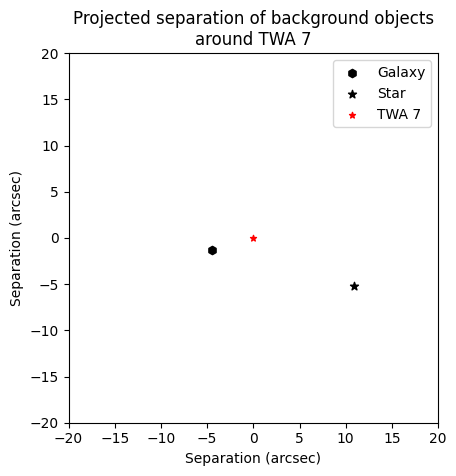

In [7]:
gstar = GStar("TWA 7")
gstar.plot(
    date = "2024-06-21"
)
import matplotlib.pyplot as plt
plt.title("Projected separation of background objects\naround TWA 7")
plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.xlabel("Separation (arcsec)")
plt.ylabel("Separation (arcsec)")
plt.scatter(0, 0, color="red", label="TWA 7", s=20, marker="*")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Since the Gaia DR3 provides effective temeprature and photometric points, one can try to fit a matching synthetic stellar spectrum. This way, it is possible to obtain the photometry of the star at any point.

___

## 5a. The NASA Exoplanet Archive

Let's start simple and take a look at what is can do. As an example, let's query information for the star LHS 1140.

In [11]:
system = NSystem("LHS 1140")
system.display()

[i] Looking at system properties
 > Star name:             LHS 1140
 > Number of planets:     2
 > Dataframe shape:       (13, 355)
 > Star:                  <NStar(LHS 1140, 13 rows)>
 > Planets:               [<NPlanet(LHS 1140 c, 6 rows)>, <NPlanet(LHS 1140 b, 7 rows)>]
 > Distance (pc):         [14.9861  0.0153 -0.0152]
 > Parallax (mas):        [66.6996     0.0673611 -0.0673611]
 > Coordinates (RA, Dec): (11.2486, -15.2741)
 > Reference:             TICv8
 > Row:                   0 [0,...,12]


This text indicates several informations. Firstly, the NASA exoplanet archive has 13 rows of information (different publications or same publication but information for different planets). One can then check various information about the system (see the Appendix). A `system` also has attributes to access stellar information of planetary information.

In [12]:
system.star.display()

[i] Star LHS 1140 properties:
 > Age (Myr):                               [  nan   nan 5000.]
 > Mass (solar masses):                     [ 0.1844  0.0045 -0.0045]
 > Radius (solar radii):                    [ 0.2159  0.003  -0.003 ]
 > Luminosity (solar luminosities):         [-2.42022  0.033   -0.03572]
 > Effective temperature (K):               [3096.   48.  -48.]
 > Irradiation temparature at 1 arcsec (K): [17.91910267  0.14173005 -0.14665736]
 > Metallicity (dex):                       [-0.15  0.09 -0.09]
 > Spectral type:                           nan
 > Reference:                               Cadieux et al. 2024
 > Row:                                     6 [0,...,12]


The convetion about the output is the following. If the first value of the array is not `np.nan`, then the first value is the actual measurement, the second value an upper uncertainty $\sigma_+$, and the third is o lowar uncertainty $\sigma_-$. If the first value of the array is `np.nan`, then the second value is an upper limit on the measurement, and the third is a lower limit.

In [13]:
system.b.display()

[i] Planet LHS 1140 b properties:
 > Letter:                       b
 > Discovery year:               2017
 > Discovery method:             Transit
 > Controversial:                False
 > Orbital period (yrs):         [ 6.77260507e-02  1.12251882e-06 -1.09514031e-06]
 > Mass (Mjup):                  [ 0.02007372  0.00144732 -0.00138439]
 > Mass sin(i) (Mjup):           [ 0.01916128  0.00151025 -0.00147879]
 > Semi-major axis (AU):         [ 0.0957  0.0019 -0.0019]
 > Eccentricity:                 [  nan 0.096   nan]
 > Inclination (deg):            [ 8.9877e+01  4.9000e-02 -4.5000e-02]
 > Argument of periastron (deg): [nan nan nan]
 > Time of periastron (JD):      [nan nan nan]
 > RV amplitude (m/s):           [ 4.21  0.24 -0.24]
 > Radius (Rjup):                [ 0.14586518  0.00410385 -0.00410385]
 > Reference:                    Lillo-Box et al. 2020
 > Row:                          2 [0,...,6]


The code chooses carefully which row to access in the dataframe, and relies on this row only to output information (this behavior however isn't guaranteed when looking separatly at star and planets). This prevents the code from taking one value in one paper, and a second value in a different paper, leading to a risk of inconsistent values.

The way the row is chosen can be looked into as follows.

In [14]:
planet_b = system.b
planet_b.display_priorities()

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 2: Lillo-Box et al. 2020 --> (0, 11, 29.5, 0.6038961038961039)
 > 1: Row 6: Cadieux et al. 2024 --> (0, 10, 29.0, 0.8071428571428572)
 > 2: Row 1: Ment et al. 2019 --> (0, 10, 29.0, 0.5714285714285714)
 > 3: Row 4: Dittmann et al. 2017 --> (0, 10, 29.0, 0.34285714285714286)
 > 4: Row 0: Edwards et al. 2021 --> (0, 10, 22.5, 0.6587301587301587)
 > 5: Row 3: Kokori et al. 2023 --> (0, 4, 12.0, 0.6964285714285714)
 > 6: Row 5: ExoFOP --> (0, 3, 7.5, 0.40476190476190477)


The column `val-notna` prioritizes rows where measurements exist, the column `err-notna` prioritizes rows where these measurements have error bars, and the column `err-range` prioritizes columns with lowest relative errors.

These three columns only consider certain rows, and one can overweight some rows if some information are more valuable than others. We will see how one can change that later.

The first column, `ref-match` allows you choose a publication (or several), by specifying and author and a date. We will see how one can use this parameter as well.

Finally, if you want to check the priorities that are currently defined, you can check the following:

In [15]:
planet_b.display_config()

[i] Current configuration for 'planet':
 > [i] References priority:
 >> empty
 > [i] Properties priority:
 >> star.age_myr:       1
 >> system.distance_pc: 1
 >> orbital_period_yrs: 2
 >> msini_mjup:         1
 >> mass_mjup:          3
 >> sma_au:             2
 >> eccentricity:       1
 >> inclination_deg:    1
 >> arg_periastron_deg: 1
 >> time_periastron_jd: 1
 >> rv_amplitude_ms:    1
 > [i] Fallback: False
 > [i] Order authors: True


For the `NPlanet` class, there are currently no specified reference(s). Certain properties are overweighted (such as the mass of the planet, which is usually more important than the rest). By default, the first authors that you define are overweighted (since `order_authors` is True). If a value is missing, the `NPlanet` class currently doesn't look in other rows if the value exists.

Note that the property `star.age_myr` allows to reference a stellar porperty of the current selected planet row. We will further look into this behavior as well.

## 5b. NASA Archive: behavior control

Let's see everything that can be done with an example.

In [16]:
from oplanet import *
from oakley import *

In [17]:
nsystem = NSystem("Beta Pictoris")
betpic_d = nsystem.d
betpic_d.display_priorities()

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 1: Sutlieff et al. 2026 --> (0, 11, 29.5, 0.7272727272727273)
 > 1: Row 0: Gibbs et al. 2026 --> (0, 11, 27.5, 0.36363636363636365)


We have two publications for *Beta Pictoris d*. Let's see what each publication contains!

In [18]:
betpic_d.display() # row 0 is the preferred one currently
betpic_d.display(1)

[i] Planet bet Pic d properties:
 > Letter:                       d
 > Discovery year:               2026
 > Discovery method:             Imaging
 > Controversial:                False
 > Orbital period (yrs):         [ 90.89664613  18.0698152  -27.10472279]
 > Mass (Mjup):                  [ 2.4  0.6 -0.6]
 > Mass sin(i) (Mjup):           [nan nan nan]
 > Semi-major axis (AU):         [26.   2.2 -6.1]
 > Eccentricity:                 [ nan 0.44  nan]
 > Inclination (deg):            [89.   0.7 -0.6]
 > Argument of periastron (deg): [nan nan nan]
 > Time of periastron (JD):      [2452641.    4000.   -4000.]
 > RV amplitude (m/s):           [nan nan nan]
 > Radius (Rjup):                [ 1.26  0.03 -0.03]
 > Reference:                    Sutlieff et al. 2026
 > Row:                          1 [0,...,1]
[i] Planet bet Pic d properties:
 > Letter:                       d
 > Discovery year:               2026
 > Discovery method:             Imaging
 > Controversial:                False

Let's now say that you prefer Gibbs publication, because you believe it to be more rigorous (having wider error bars on the measurements is often a good sign). You can specifiy it the following way:

In [19]:
betpic_d.add_reference_priority(
    author="Gibbs", # the algorithm looks for this
    # in the reference name => putting a substring
    # is enough, "Gib" would work as well.
    date = "2026" # optionnal, use it in case one 
    # author has made multiple papers for one target
)
betpic_d.display_priorities()

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 0: Gibbs et al. 2026 --> (1, 11, 27.5, 0.36363636363636365)
 > 1: Row 1: Sutlieff et al. 2026 --> (0, 11, 29.5, 0.7272727272727273)


*Gibbs et al. 2026* is now the preferred reference! Let's forget about the reference, and let's say that you specifically want the time of peristron, which only one of both papers provide. This is a good occasion to show you how to access the reference used for a given measurement.

In [20]:
betpic_d.reset_config()
Message("Time of periastron").list({
    "Value": betpic_d.time_periastron_jd,
    "Reference": betpic_d.last_used_reference()[0]
})
betpic_d.add_property_priority("time_periastron_jd", 100) # overweight it so that this is all that matters
Message("Time of periastron").list({
    "Value": betpic_d.time_periastron_jd,
    "Reference": betpic_d.last_used_reference()[0]
})


[i] Time of periastron
 > Value:     [nan nan nan]
 > Reference: Gibbs et al. 2026
[i] Time of periastron
 > Value:     [2452641.    4000.   -4000.]
 > Reference: Sutlieff et al. 2026


There is actually a second way to gain access to values that are missing from one row but exist in an other row. This corresponds to the parameter *fallback*.

In [21]:
betpic_d.reset_config(refresh_objects=[betpic_d])
betpic_d.set_fallback(True)
betpic_d.display_priorities()
Message("Argument of periastron").list({
    "Value": betpic_d.arg_periastron_deg,
    "Reference for Value": betpic_d.last_used_reference()[0],
    "Row reference": betpic_d.reference
})

[?] Row priorities for planet: (ref-match, val-notna, err-notna, err-range)
 > 0: Row 1: Sutlieff et al. 2026 --> (0, 11, 29.5, 0.7272727272727273)
 > 1: Row 0: Gibbs et al. 2026 --> (0, 11, 27.5, 0.36363636363636365)
[i] Argument of periastron
 > Value:               [ 191.  127. -149.]
 > Reference for Value: Sutlieff et al. 2026
 > Row reference:       Sutlieff et al. 2026


Here, missing values are replaced by a different row.

Here is a few things to note:
- when a priority is added or removed (author or property), the object is automatically refreshed, so that a new row might be chosen. The single other method that might change the chosen row is `reset_config`, but, as it is a static method, it doesn't update existing objects, and one has to call refresh on every single one of them, or pass them in arguments to the `reset_config` method.
- changes to the config are global, hence, `reset_config` will not only update for the current used class, but for all of them (systme, star, planet). However, all the parameters we changed above were only changed for the current class (so planets) and not for the rest.
- if you want the current priorities to become permanent, use `oplanet_config.dump()` to save everything to a synchronized `json` file. If you want to reset the default configuration to the original default configuration (akak the default default configuration), use `oplanet_config.reset_default()`.

We need to talk about nested properties as well. Let's take a look!

In [22]:
nsystem.c.display(0)

[i] Planet bet Pic c properties:
 > Letter:                       c
 > Discovery year:               2019
 > Discovery method:             Radial Velocity
 > Controversial:                False
 > Orbital period (yrs):         [ 3.36755647  0.03832991 -0.03832991]
 > Mass (Mjup):                  [ 8.2  0.8 -0.8]
 > Mass sin(i) (Mjup):           [nan nan nan]
 > Semi-major axis (AU):         [ 2.72  0.02 -0.02]
 > Eccentricity:                 [ 0.37  0.12 -0.12]
 > Inclination (deg):            [89.17  0.5  -0.5 ]
 > Argument of periastron (deg): [66.2  2.5 -2.5]
 > Time of periastron (JD):      [nan nan nan]
 > RV amplitude (m/s):           [nan nan nan]
 > Radius (Rjup):                [nan nan nan]
 > Reference:                    Nowak et al. 2020
 > Row:                          0 [0,...,3]


In [23]:
nsystem.reset_config()
nsystem.b.add_reference_priority("Lagrange", 2009)
nsystem.c.add_reference_priority("Lagrange", 2019)
nsystem.c.set_order_authors(True) # Lagrange 2009 > Lagrange 2019
Message("Nested property behavior").list({
    "system.star.reference": nsystem.star.reference,
    "system.b.reference": nsystem.b.reference,
    "system.b.star.reference": nsystem.b.star.reference,
    "system.c.reference": nsystem.c.reference,
    "system.c.star.reference": nsystem.c.star.reference
})
#nsystem.reset_config()

[i] Nested property behavior
 > system.star.reference:   Sutlieff et al. 2026
 > system.b.reference:      Lagrange et al. 2009
 > system.b.star.reference: TICv8
 > system.c.reference:      Lagrange et al. 2019
 > system.c.star.reference: Lagrange et al. 2019


As mentionned before, a star or planet corresponds to one row of the dataframe, whosen based on the priorities. Calling the attribute `planet.star` returns a star object containing only the currently chosen row for the planet, which might differ from the reference used by default when calling `nsystem.star`. Hence, for planet c, the reference used for the star is the same as for the planet, which differes from the reference used by default, according to preferences. For planet b, the reference differs because within one single row there might be a different reference for the star and the planet (when there is no stellar information in the planet paper i guess, or the reference could be the same reference that was used in the planet paper).

Finally, it can be usefull to obtain the references that were used. For this, one can obtain a dataframe and convert it to a Latex Table:

In [24]:
nsystem.b.display()

[i] Planet bet Pic b properties:
 > Letter:                       b
 > Discovery year:               2008
 > Discovery method:             Imaging
 > Controversial:                False
 > Orbital period (yrs):         [16.42710472         nan         nan]
 > Mass (Mjup):                  [ 8.  4. -2.]
 > Mass sin(i) (Mjup):           [nan nan nan]
 > Semi-major axis (AU):         [ 8. nan nan]
 > Eccentricity:                 [nan nan nan]
 > Inclination (deg):            [nan nan nan]
 > Argument of periastron (deg): [nan nan nan]
 > Time of periastron (JD):      [nan nan nan]
 > RV amplitude (m/s):           [nan nan nan]
 > Radius (Rjup):                [nan nan nan]
 > Reference:                    Lagrange et al. 2009
 > Row:                          4 [0,...,10]


In [25]:
print(nsystem.b.ref_latex(attributes={
    "mass_mjup": r"Mass [$M_{Jup}$]",
    "sma_au": r"SMA [AU]",
    "orbital_period_yrs": r"$P_{orb}$ [yr]",
    "star.age_myr": r"$\tau_{star}$ [Myr]"
}))

\begin{table}
\caption{bet Pic b parameters summary}
\begin{tabular}{lcc}
\toprule
Attribute & Value & Reference \\
\midrule
Mass [$M_{Jup}$] & $8.00^{+4.00}_{-2.00}$ & \href{ https://ui.adsabs.harvard.edu/abs/2009A&A...493L..21L/abstract }{Lagrange et al. 2009} \\
SMA [AU] & $8.00$ & \href{ https://ui.adsabs.harvard.edu/abs/2009A&A...493L..21L/abstract }{Lagrange et al. 2009} \\
$P_{orb}$ [yr] & $16.43$ & \href{ https://ui.adsabs.harvard.edu/abs/2009A&A...493L..21L/abstract }{Lagrange et al. 2009} \\
$\tau_{star}$ [Myr] & --- & --- \\
\bottomrule
\end{tabular}
\end{table}



Let's check other examples! For instance, the reference is correctly tracked when the fallback parameter let's it look in different rows.

In [26]:
nsystem = NSystem("Beta Pictoris")
star = nsystem.star
star.add_reference_priority("Feng")
star.set_fallback(False)
df = star.ref_df(attributes=["mass_msun", "age_myr"])
Message("References (no fallback):").list({
    "Mass": f"{df.iloc[0]["Value"]} || " + df.iloc[0]["Reference"],
    "Age": f"{df.iloc[1]["Value"]} || " + df.iloc[1]["Reference"]
})
star.set_fallback(True)
df = star.ref_df(attributes=["mass_msun", "age_myr"])
Message("References (with fallback):").list({
    "Mass": f"{df.iloc[0]["Value"]} || " + df.iloc[0]["Reference"],
    "Age": f"{df.iloc[1]["Value"]} || " + df.iloc[1]["Reference"]
})

[i] References (no fallback):
 > Mass: $1.79^{+0.03}_{-0.03}$ || \href{ https://ui.adsabs.harvard.edu/abs/2022ApJS..262...21F/abstract }{Feng et al. 2022}
 > Age:  --- || ---
[i] References (with fallback):
 > Mass: $1.79^{+0.03}_{-0.03}$ || \href{ https://ui.adsabs.harvard.edu/abs/2022ApJS..262...21F/abstract }{Feng et al. 2022}
 > Age:  $16.50^{+4.50}_{-4.50}$ || \href{ https://ui.adsabs.harvard.edu/abs/2026arXiv260623801S/abstract }{Sutlieff et al. 2026}


Additionnaly, when a provided value is an upper or lower limit, it gets displayed correctly as well.

In [27]:
nsystem = NSystem("LHS 1140")
star = nsystem.star
df = star.ref_df(attributes=["mass_msun", "age_myr"])
Message("References:").list({
    "Mass": f"{df.iloc[0]["Value"]} || " + df.iloc[0]["Reference"],
    "Age": f"{df.iloc[1]["Value"]} || " + df.iloc[1]["Reference"]
})

[i] References:
 > Mass: $0.18^{+0.00}_{-0.00}$ || \href{ https://ui.adsabs.harvard.edu/abs/2024ApJ...960L...3C/abstract }{Cadieux et al. 2024}
 > Age:  $>5000.00$ || \href{ https://ui.adsabs.harvard.edu/abs/2019AJ....157...32M/abstract }{Ment et al. 2019}


___

## Appendix
```python
# 1. Available @property for SFilter
sfilter = SFilter("F1500W")
sfilter.name                  # filter short name
sfilter.id                    # unique SVO identifier
sfilter.wl_mean               # mean wavelength (m)
sfilter.wl_pivot              # pivot wavelength (m)
sfilter.wl_eff                # effective wavelength (m)
sfilter.effective_bandwidth  # normalized bandwidth (m)
sfilter.bandwidth             # bandwidth (m)
sfilter.fwhm                  # full width at half maximum (m)
sfilter.wl_min                # min wavelength at 1% transmission (m)
sfilter.wl_max                # max wavelength at 1% transmission (m)
sfilter.wl_central            # central wavelength (m)
sfilter.wl_peak               # peak-transmission wavelength (m)
sfilter.detector_type         # detector type
sfilter.wl                    # transmission-curve wavelengths (m)
sfilter.tr                    # transmission-curve values

# 2. Available @property for NSystem
system = NSystem("Beta Pictoris")
system.columns           # available columns (suffixes grouped)
system.name              # system/star name
system.distance_pc       # distance (pc)
system.parallax_mas      # parallax (mas)
system.ra                # right ascension (deg)
system.dec               # declination (deg)
system.aliases           # Simbad aliases
system.reference_date    # reference year
system.reference_author  # reference author
system.reference_url     # reference URL
system.reference         # formatted reference string
system.star              # NStar view
system.a                 # alias for system.star
system.A                 # alias for system.star
system.n_planets         # number of detected planets
system.planets           # list of NPlanet objects
system.b                 # planet b
system.c                 # planet c
system.d                 # planet d
system.e                 # planet e
system.f                 # planet f
system.g                 # planet g
system.h                 # planet h
system.i                 # planet i
system.j                 # planet j (lol)

# 3. Available @property for NStar
star = system.star
# NStar inherits NSystem properties and adds:
star.age_myr          # age (Myr)
star.mass_solar       # stellar mass (Msun)
star.radius_solar     # stellar radius (Rsun)
star.luminosity_solar # stellar luminosity (Lsun)
star.Teff_k           # effective temperature (K)
star.metallicity_dex  # metallicity (dex)
star.spectral_type    # spectral type
star.system           # NSystem view for the same chosen row

# 4. Available @property for NPlanet
planet = system.b
# NPlanet inherits NSystem properties and adds:
planet.name               # full planet name
planet.letter             # planet letter
planet.discovery_year     # discovery year
planet.discovery_method   # discovery method
planet.orbital_period_yrs # orbital period (yr)
planet.mass_sini_mjup     # M sin(i) (Mjup)
planet.mass_mjup          # planet mass (Mjup)
planet.sma_au             # semi-major axis (AU)
planet.eccentricity       # orbital eccentricity
planet.inclination_deg    # inclination (deg)
planet.arg_periastron_deg # argument of periastron (deg)
planet.time_periastron_jd # time of periastron (JD)
planet.rv_amplitude_ms    # RV amplitude (m/s)
planet.radius_rjup        # radius (Rjup)
planet.star               # NStar view for the same chosen row
planet.system             # NSystem view for the same chosen row
```